# Tempo Memo Analytics

Analysis of TransferWithMemo events on Moderato testnet (pathUSD).

Data sources:
- `memos-all.csv` — **full chain history**, ~6.55M blocks (block 0 → head), generated by `scan-incremental.ts`
- `memos-month.csv` — ~30 days, ~5.2M blocks, 525k events
- `memos-week.csv` — ~7 days, ~1.2M blocks, 37k events

Change `DATA_FILE` below to switch between datasets.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np
import re

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

# ── Pick dataset ──────────────────────────────────────────────
DATA_FILE = 'memos-all.csv'        # full history (~6.55M blocks)
# DATA_FILE = 'memos-month.csv'    # 30 days
# DATA_FILE = 'memos-week.csv'     # 7 days

TOTAL_CHAIN_BLOCKS = 6_551_288     # approx chain height at scan time

df = pd.read_csv(DATA_FILE, low_memory=False)
df = df.dropna(subset=['block_number'])

print(f'Dataset: {DATA_FILE}')
print(f'Total events: {len(df):,}')
print(f'Block range: {df.block_number.min():,.0f} — {df.block_number.max():,.0f}')
block_span = df.block_number.max() - df.block_number.min()
hours = block_span * 0.5 / 3600
print(f'Block span: {block_span:,.0f} blocks (~{hours:.0f} hours / {hours/24:.1f} days)')
if block_span > TOTAL_CHAIN_BLOCKS * 0.9:
    print(f'Coverage: FULL CHAIN HISTORY')
else:
    print(f'Coverage: {block_span/TOTAL_CHAIN_BLOCKS*100:.1f}% of chain')
print(f'Unique txs: {df.tx_hash.nunique():,}')
print(f'Unique senders: {df["from"].nunique():,}')
print(f'Unique receivers: {df["to"].nunique():,}')
df.head()

Dataset: memos-all.csv
Total events: 654,980
Block range: 17,538 — 6,643,148
Block span: 6,625,610 blocks (~920 hours / 38.3 days)
Coverage: FULL CHAIN HISTORY
Unique txs: 630,640
Unique senders: 88,072
Unique receivers: 353,961


,block_number,tx_hash,log_index,from,to,amount_raw,amount_human,memo_raw,memo_format,memo_decoded,memo_v1_type,memo_v1_ulid,memo_v1_issuer_tag
0,17538.0,0x1f0bdc6343d2b983d44d0e79300a2460262cf4f4d555...,1.0,0xf9a54cC86dbb6696bfdddB13C55d269F7f71eb24,0xEbcbE0d270ec87ce4b0e85d444172E08161281e8,10000.0,0.01,0x746573742d6d656d6f00000000000000000000000000...,text,test-memo,NaN,NaN,NaN
1,17665.0,0x6baea30eab95b63c327efbbc78d5dbddbaa8148afd2b...,17.0,0x37FccA747BA5dA9A57c42c403679C4f437416c6e,0x2FA86AD1D29F65B015Ed0705B3399815708a4d93,10000.0,0.01,0x746573742d6d656d6f00000000000000000000000000...,text,test-memo,NaN,NaN,NaN
2,17834.0,0xdfd17c97044015b98a27b57adbb9920de366ff100836...,33.0,0xA1E180A92956BC20e93B6126918028cfEfc5BcBc,0x13e8632a7Bd1c27f962b6fD677863004a5a13fA7,10000.0,0.01,0x746573742d6d656d6f00000000000000000000000000...,text,test-memo,NaN,NaN,NaN
3,17973.0,0xb9468d3d3a9b45118a2d68846f1fa4690e9cc3a2c216...,1.0,0x1B67BaF3422c90E93F377cfC4558388819705763,0x1b333Efe4b0D149f562cEF9D1a080D690E6017eC,10000.0,0.01,0x746573742d6d656d6f00000000000000000000000000...,text,test-memo,NaN,NaN,NaN
4,18129.0,0x54a029d209e007a83ca1c7a26d73c455861965cc0f66...,1.0,0xd58E4DAb39F5C3d76d7A707DE6736169682a7075,0x4dA037F30CBe9D7AD614B28b8574A4153B0D327e,10000.0,0.01,0x746573742d6d656d6f00000000000000000000000000...,text,test-memo,NaN,NaN,NaN


## Reclassified format distribution

The raw decoder classifies "binary" anything it can't parse. But many "binary" memos are actually
left-padded text (zeros on the left, text on the right — Solidity's natural `bytes32` cast).

Let's reclassify properly.

Reclassified format distribution:
  text                      482,842  (73.7%)
  binary                    158,367  (24.2%)
  protocol (0xef1ed712)      9,921  (1.5%)
  false-positive v1          3,850  (0.6%)


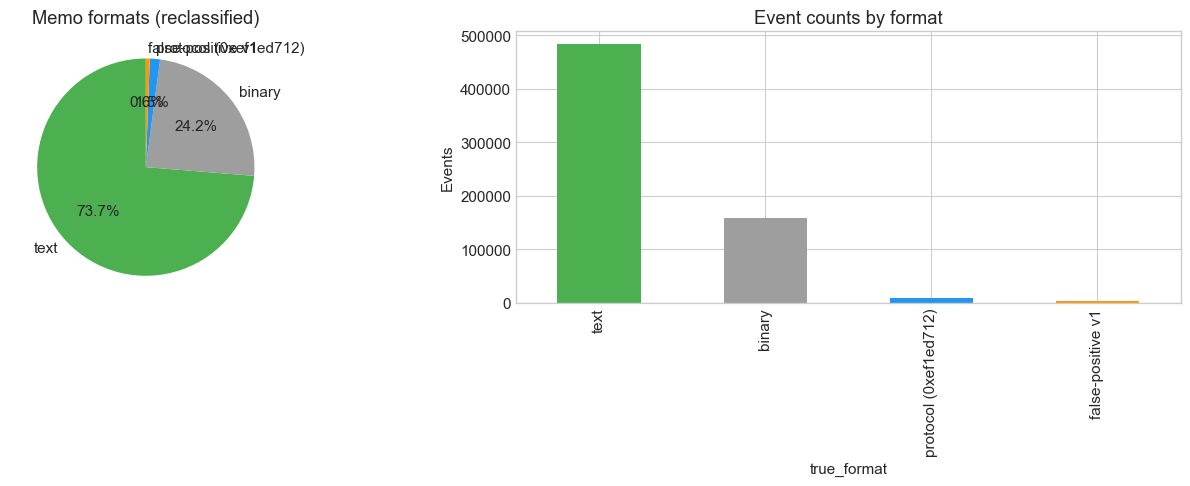

In [2]:
def decode_left_padded(raw):
    """Decode bytes32 with leading zeros and right-aligned ASCII text."""
    h = raw[2:] if raw.startswith('0x') else raw
    stripped = h.lstrip('0')
    if len(stripped) % 2 != 0:
        stripped = '0' + stripped
    if not stripped:
        return None
    try:
        bs = bytes.fromhex(stripped)
        for b in bs:
            if b < 0x20 or b > 0x7e:
                if b not in (0x09, 0x0a, 0x0d):
                    return None
        return bs.decode('ascii')
    except:
        return None

# Reclassify binary memos
bin_df = df[df.memo_format == 'binary'].copy()
bin_df['left_text'] = bin_df.memo_raw.apply(decode_left_padded)
left_text_mask = bin_df.left_text.notna()
ef_mask = bin_df.memo_raw.str.startswith('0xef1ed712')

# Build reclassified column
df['true_format'] = df.memo_format.copy()
bin_idx_left = bin_df[left_text_mask].index
bin_idx_ef = bin_df[ef_mask & ~left_text_mask].index

df.loc[bin_idx_left, 'true_format'] = 'left-padded text'
df.loc[bin_idx_ef, 'true_format'] = 'protocol (0xef1ed712)'

# v1 "matches" are false positives — random bytes that happen to pass validation.
# No real v1 structured memos exist on-chain yet (all issuer tags are unique/random,
# ULIDs don't decode to valid timestamps, uniform distribution across all type codes).
df.loc[df.memo_format == 'v1', 'true_format'] = 'false-positive v1'

# Also decode left-padded text into memo_decoded
df.loc[bin_idx_left, 'memo_decoded'] = bin_df.loc[left_text_mask, 'left_text']

fmt_counts = df.true_format.value_counts()
print('Reclassified format distribution:')
for fmt, cnt in fmt_counts.items():
    print(f'  {fmt:<25} {cnt:>6,}  ({cnt/len(df)*100:.1f}%)')

COLOR_MAP = {
    'text': '#4CAF50',
    'left-padded text': '#8BC34A',
    'protocol (0xef1ed712)': '#2196F3',
    'false-positive v1': '#FF9800',
    'binary': '#9E9E9E',
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fmt_counts.plot.pie(ax=ax1, autopct='%1.1f%%', startangle=90,
                     colors=[COLOR_MAP.get(x, '#ccc') for x in fmt_counts.index])
ax1.set_ylabel('')
ax1.set_title('Memo formats (reclassified)')

fmt_counts.plot.bar(ax=ax2, color=[COLOR_MAP.get(x, '#ccc') for x in fmt_counts.index])
ax2.set_title('Event counts by format')
ax2.set_ylabel('Events')
plt.tight_layout()
plt.show()

## Event volume over time

Block number as proxy for time (each block = 0.5s).

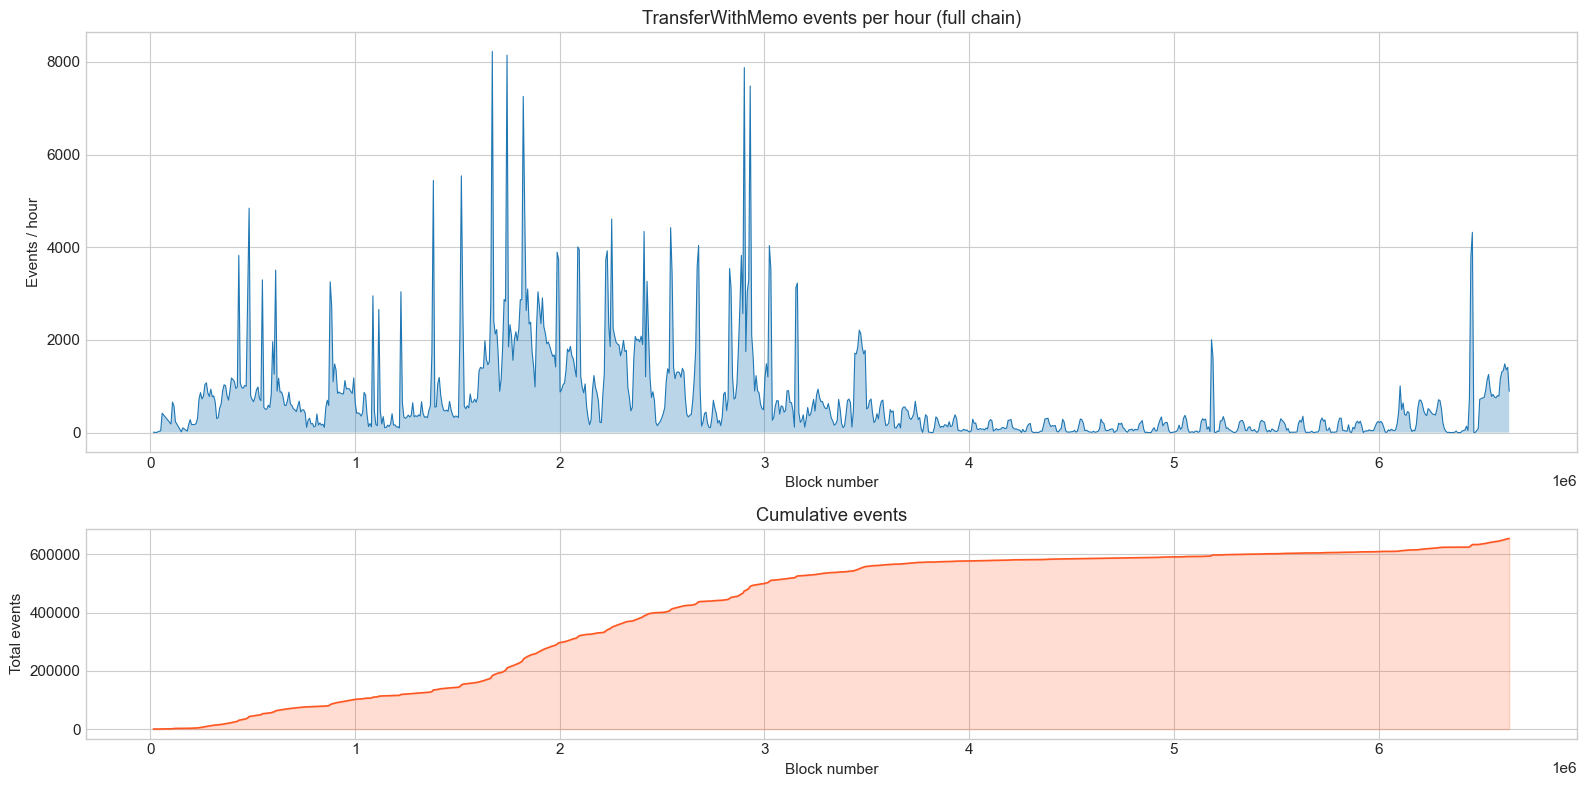

Average events/hour: 727.8
Peak hour: 8228 events at block 1670400.0
Empty hours: 0
Total hours covered: 900

Daily stats (39 days):
  Average: 16,794 events/day
  Peak:    67,755 events on day starting at block 1728000.0
  Quiet:   1,877 events on day starting at block 4665600.0


In [3]:
# Bin blocks into ~1-hour windows (7200 blocks = 1 hour at 0.5s)
BLOCKS_PER_HOUR = 7200
df['hour_bin'] = (df.block_number // BLOCKS_PER_HOUR) * BLOCKS_PER_HOUR

hourly = df.groupby('hour_bin').size()

fig, axes = plt.subplots(2, 1, figsize=(16, 8), gridspec_kw={'height_ratios': [2, 1]})

# Top: full timeline
ax1 = axes[0]
hourly.plot(ax=ax1, kind='line', linewidth=0.8)
ax1.set_title('TransferWithMemo events per hour (full chain)')
ax1.set_xlabel('Block number')
ax1.set_ylabel('Events / hour')
ax1.fill_between(hourly.index, hourly.values, alpha=0.3)

# Bottom: cumulative
ax2 = axes[1]
cumulative = hourly.cumsum()
cumulative.plot(ax=ax2, linewidth=1.2, color='#FF5722')
ax2.set_title('Cumulative events')
ax2.set_xlabel('Block number')
ax2.set_ylabel('Total events')
ax2.fill_between(cumulative.index, cumulative.values, alpha=0.2, color='#FF5722')

plt.tight_layout()
plt.show()

print(f'Average events/hour: {hourly.mean():.1f}')
print(f'Peak hour: {hourly.max()} events at block {hourly.idxmax()}')
print(f'Empty hours: {(hourly == 0).sum()}')
print(f'Total hours covered: {len(hourly):,}')

# Weekly aggregation for long time spans
BLOCKS_PER_DAY = BLOCKS_PER_HOUR * 24
df['day_bin'] = (df.block_number // BLOCKS_PER_DAY) * BLOCKS_PER_DAY
daily = df.groupby('day_bin').size()
print(f'\nDaily stats ({len(daily)} days):')
print(f'  Average: {daily.mean():,.0f} events/day')
print(f'  Peak:    {daily.max():,} events on day starting at block {daily.idxmax()}')
print(f'  Quiet:   {daily.min():,} events on day starting at block {daily.idxmin()}')

## All text memos (right-padded + left-padded combined)

Majority of events are human-readable text. Let's look at both padding styles together across the full chain history.

All text memos: 482,842 (73.7%)
  Right-padded: 482,842
  Left-padded:  0
  Unique values: 117,677

Top 40 text memos (both padding styles):
  268444x  [R] "test-memo"
    854x  [R] "drop"
    844x  [R] "flick"
    830x  [R] "block"
    829x  [R] "crypto"
    823x  [R] "bit"
    821x  [R] "snap"
    816x  [R] "pulse"
    815x  [R] "glow"
    810x  [R] "hash"
    802x  [R] "flux"
    798x  [R] "mint"
    797x  [R] "tap"
    796x  [R] "node"
    789x  [R] "chain"
    788x  [R] "drip"
    779x  [R] "rise"
    773x  [R] "beam"
    752x  [R] "flash"
    749x  [R] "spark"
    746x  [R] "wave"
    694x  [R] "Uber rides - Jan week"
    688x  [R] "Content writing - 10 articles"
    685x  [R] "Service credit applied"
    683x  [R] "Stipend - Remote work"
    683x  [R] "Notion Team Plan"
    678x  [R] "Netflix - Monthly"
    674x  [R] "SSL certificate renewal"
    672x  [R] "Commission payment"
    672x  [R] "Website redesign - Phase 1"
    671x  [R] "Mobile app UI/UX"
    669x  [R] "Lunch reimbu

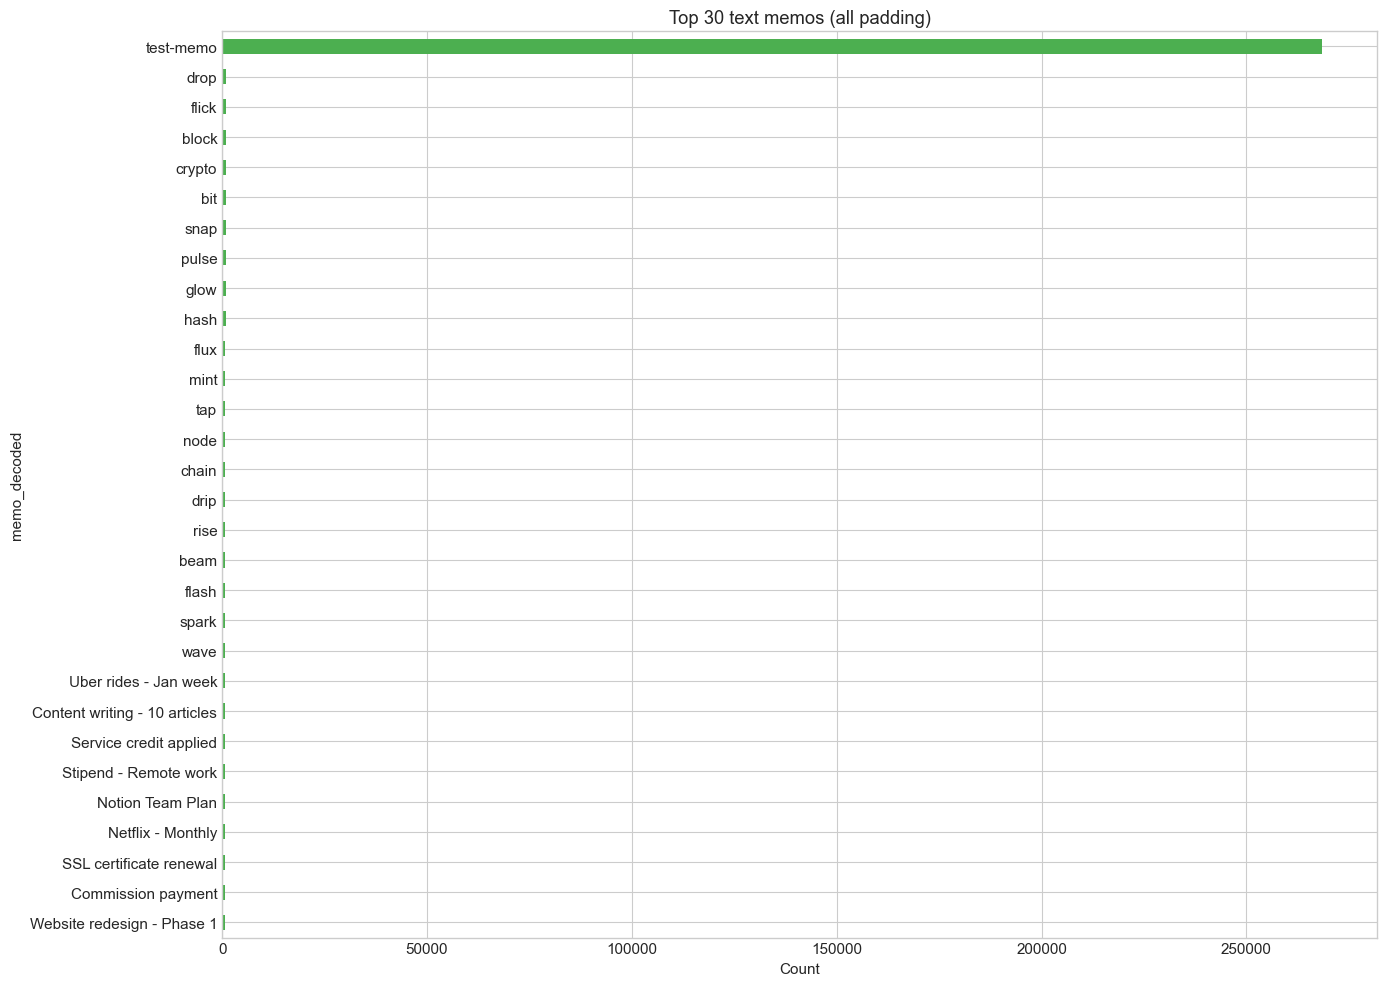

In [4]:
all_text = df[df.true_format.isin(['text', 'left-padded text'])].copy()
print(f'All text memos: {len(all_text):,} ({len(all_text)/len(df)*100:.1f}%)')
print(f'  Right-padded: {(all_text.true_format == "text").sum():,}')
print(f'  Left-padded:  {(all_text.true_format == "left-padded text").sum():,}')
print(f'  Unique values: {all_text.memo_decoded.nunique():,}\n')

top_all = all_text.memo_decoded.value_counts().head(40)
print('Top 40 text memos (both padding styles):')
for val, cnt in top_all.items():
    pad = all_text[all_text.memo_decoded == val].true_format.iloc[0]
    tag = 'R' if pad == 'text' else 'L'
    print(f'  {cnt:>5}x  [{tag}] "{val}"')

fig, ax = plt.subplots(figsize=(14, 10))
top_all.head(30).plot.barh(ax=ax, color='#4CAF50')
ax.set_title('Top 30 text memos (all padding)')
ax.set_xlabel('Count')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

Memo categories:
  test                 268,862  (55.7%)
  other                101,760  (21.1%)
  numbered-note        27,684  (5.7%)
  single-word          22,771  (4.7%)
  payment-ref          20,924  (4.3%)
  invoice              16,225  (3.4%)
  ticket-number        11,398  (2.4%)
  daily-expense         4,039  (0.8%)
  business-service      3,973  (0.8%)
  tip/thanks            2,987  (0.6%)
  recurring               912  (0.2%)
  payroll                 627  (0.1%)
  bill-split              467  (0.1%)
  swap/dex                213  (0.0%)


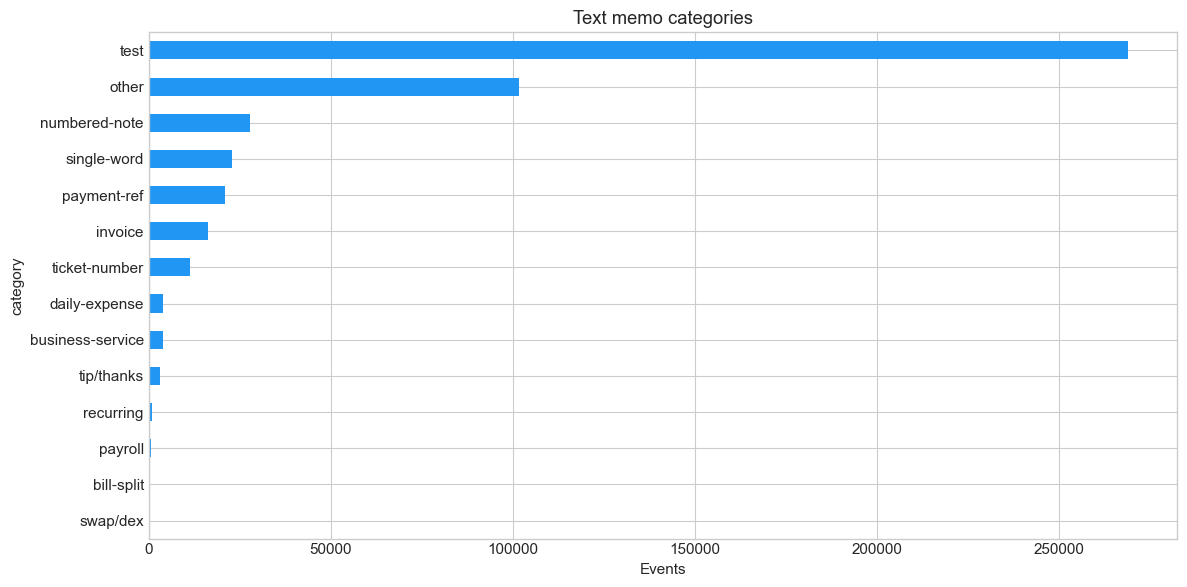


Examples per category:
  test: "test-memo" (268444x), "test" (176x), "TestMemo" (98x)
  other: "Service credit applied" (685x), "Stipend - Remote work" (683x), "Notion Team Plan" (683x)
  numbered-note: "Note #954" (18x), "Note #298" (15x), "Memo #628" (14x)
  single-word: "drop" (854x), "flick" (844x), "block" (830x)
  payment-ref: "payment001" (121x), "payment002" (114x), "payment003" (83x)
  invoice: "Invoice #2026-906 - Cloud Servi" (6x), "INV-343 - Consulting Fee" (5x), "INV-169 - Software License" (5x)
  ticket-number: "#667405001" (2x), "#726284005" (2x), "#368124002" (2x)
  daily-expense: "Uber rides - Jan week" (694x), "Lunch reimbursement" (669x), "dinner001" (167x)
  business-service: "Content writing - 10 articles" (688x), "Website redesign - Phase 1" (672x), "Figma Organization" (665x)
  tip/thanks: "thanks!002" (124x), "thanks!001" (115x), "thanks!003" (97x)
  recurring: "rent001" (135x), "utilities002" (128x), "utilities001" (122x)
  payroll: "Salary - Jan 2026" (621x),

In [5]:
# Categorize text memos by semantic meaning
import re

def categorize_memo(text):
    if not isinstance(text, str):
        return 'unknown'
    t = text.lower().strip()
    if re.match(r'^(inv-|invoice)', t): return 'invoice'
    if re.match(r'^(pay-|payment)', t): return 'payment-ref'
    if re.match(r'^(salary|payroll)', t): return 'payroll'
    if t.startswith('swap:'): return 'swap/dex'
    if re.match(r'^(rent|utilities|subscription)', t): return 'recurring'
    if re.match(r'^(dinner|lunch|coffee|groceries|uber|gas|taxi|food)', t): return 'daily-expense'
    if re.match(r'^(thx-|thanks|tip)', t): return 'tip/thanks'
    if re.match(r'^(split|shared)', t): return 'bill-split'
    if re.match(r'^(note|memo|message|msg) ?#', t): return 'numbered-note'
    if re.match(r'^(website|content|software|figma|stripe|bandwidth|hosting)', t): return 'business-service'
    if re.match(r'^test', t): return 'test'
    if re.match(r'^(#\d)', t): return 'ticket-number'
    if len(t.split()) == 1 and len(t) <= 8: return 'single-word'
    return 'other'

all_text['category'] = all_text.memo_decoded.apply(categorize_memo)

cat_counts = all_text.category.value_counts()
print('Memo categories:')
for cat, cnt in cat_counts.items():
    pct = cnt / len(all_text) * 100
    print(f'  {cat:<20} {cnt:>6,}  ({pct:.1f}%)')

fig, ax = plt.subplots(figsize=(12, 6))
cat_counts.plot.barh(ax=ax, color='#2196F3')
ax.set_title('Text memo categories')
ax.set_xlabel('Events')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# Show examples from each category
print('\nExamples per category:')
for cat in cat_counts.index:
    examples = all_text[all_text.category == cat].memo_decoded.value_counts().head(3)
    ex_str = ', '.join(f'"{v}" ({c}x)' for v, c in examples.items())
    print(f'  {cat}: {ex_str}')

## "V1 structured" memos — all false positives

The decoder flags ~0.6% of memos as v1 format. But these are random bytes that happen to start
with a valid type byte (0x01–0x05, 0x0F). Let's prove they're noise.

In [6]:
v1_df = df[df.memo_format == 'v1'].copy()
print(f'Memos passing v1 validation: {len(v1_df):,} ({len(v1_df)/len(df)*100:.1f}%)\n')

if len(v1_df) == 0:
    print('No v1 memos found at all.')
else:
    # Evidence 1: type codes are uniformly distributed (real usage would cluster)
    type_counts = v1_df.memo_v1_type.value_counts()
    print('Evidence 1 — Type code distribution (should cluster if real):')
    for t, cnt in type_counts.items():
        print(f'  {t:<15} {cnt:>5}  ({cnt/len(v1_df)*100:.1f}%)')
    expected_per_type = len(v1_df) / len(type_counts)
    chi_sq = sum((cnt - expected_per_type)**2 / expected_per_type for cnt in type_counts)
    print(f'  Chi-squared vs uniform: {chi_sq:.1f} (low = uniform = random)')

    # Evidence 2: all issuer tags are unique/near-unique (real usage would repeat)
    unique_tags = v1_df.memo_v1_issuer_tag.nunique()
    print(f'\nEvidence 2 — Issuer tags:')
    print(f'  Unique tags: {unique_tags:,} out of {len(v1_df):,} memos')
    print(f'  Ratio: {unique_tags/len(v1_df)*100:.1f}% unique (real apps would reuse 1-2 tags)')

    # Evidence 3: ULID timestamps don't decode to valid dates
    # ULID bytes 0-5 are timestamp (ms since epoch). Check if they fall in a reasonable range.
    def ulid_timestamp_ms(ulid_str):
        """Extract timestamp from ULID string (first 10 chars = 48-bit timestamp)."""
        try:
            crockford = '0123456789ABCDEFGHJKMNPQRSTVWXYZ'
            val = 0
            for ch in ulid_str[:10].upper():
                val = val * 32 + crockford.index(ch)
            return val
        except:
            return None

    v1_df['ulid_ts'] = v1_df.memo_v1_ulid.apply(ulid_timestamp_ms)
    valid_ts = v1_df.ulid_ts.dropna()
    # Valid range: 2024-01-01 to 2027-01-01
    ts_2024 = 1704067200000
    ts_2027 = 1798761600000
    in_range = ((valid_ts >= ts_2024) & (valid_ts <= ts_2027)).sum()
    print(f'\nEvidence 3 — ULID timestamps:')
    print(f'  With valid timestamp (2024-2027): {in_range} out of {len(valid_ts):,}')
    print(f'  Ratio: {in_range/max(len(valid_ts),1)*100:.1f}% (real ULIDs would be ~100%)')

    # Evidence 4: expected false positive rate
    # 6 valid type codes out of 256 possible first bytes → 6/256 = 2.34% of random bytes pass
    binary_total = (df.memo_format == 'binary').sum() + len(v1_df)
    expected_fp = binary_total * 6 / 256
    print(f'\nEvidence 4 — Expected false positive rate:')
    print(f'  Binary + "v1" memos: {binary_total:,}')
    print(f'  Expected false positives (6/256): {expected_fp:,.0f}')
    print(f'  Actual "v1" detections: {len(v1_df):,}')
    print(f'  Ratio actual/expected: {len(v1_df)/max(expected_fp,1):.2f}x')

    print(f'\nConclusion: ALL {len(v1_df):,} "v1" memos are false positives.')
    print('Random binary data with byte[0] in {{0x01-0x05, 0x0F}}.')

Memos passing v1 validation: 3,850 (0.6%)

Evidence 1 — Type code distribution (should cluster if real):
  custom            658  (17.1%)
  batch             644  (16.7%)
  subscription      644  (16.7%)
  refund            642  (16.7%)
  invoice           638  (16.6%)
  payroll           624  (16.2%)
  Chi-squared vs uniform: 0.9 (low = uniform = random)

Evidence 2 — Issuer tags:
  Unique tags: 3,848 out of 3,850 memos
  Ratio: 99.9% unique (real apps would reuse 1-2 tags)

Evidence 3 — ULID timestamps:
  With valid timestamp (2024-2027): 1 out of 3,850
  Ratio: 0.0% (real ULIDs would be ~100%)

Evidence 4 — Expected false positive rate:
  Binary + "v1" memos: 172,138
  Expected false positives (6/256): 4,034
  Actual "v1" detections: 3,850
  Ratio actual/expected: 0.95x

Conclusion: ALL 3,850 "v1" memos are false positives.
Random binary data with byte[0] in {{0x01-0x05, 0x0F}}.


## The 0xef1ed712 protocol

A significant portion of all events use this prefix. Every value is unique. Tiny amounts. What is it?

0xef1ed712 events: 9,921
All unique: True
Middle section all zeros: 0 / 9,921 (0.0%)

Amount stats:
  Median: 0.0200 pathUSD
  Mean:   0.0383 pathUSD
  Min:    0.000100 pathUSD
  Max:    1.00 pathUSD
  Total:  380.03 pathUSD
  Senders: 668, Receivers: 251


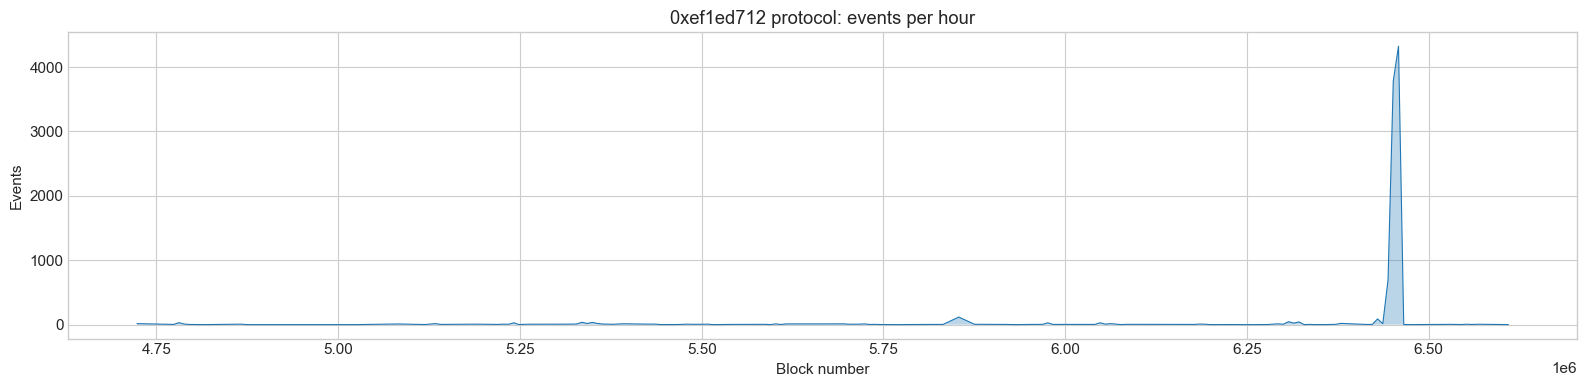


Structure: ef1ed71201 + 10 variable bytes + 11 zero bytes + 6 variable bytes
Looks like: protocol_prefix(5B) + identifier(10B) + padding(11B) + nonce/hash(6B)
Possibly a tracking/attestation system with unique transaction IDs.


In [7]:
ef_df = df[df.true_format == 'protocol (0xef1ed712)'].copy()
print(f'0xef1ed712 events: {len(ef_df):,}')
print(f'All unique: {ef_df.memo_raw.nunique() == len(ef_df)}')

# Analyze the structure
# Common prefix: 0xef1ed71201 (5 bytes), then variable
ef_df['prefix_10'] = ef_df.memo_raw.str[:30]  # first 15 bytes
ef_df['suffix_6'] = ef_df.memo_raw.str[-12:]  # last 6 bytes (variable)

# Check: is the middle always zeros?
ef_df['mid_section'] = ef_df.memo_raw.str[30:52]
all_zeros_mid = (ef_df.mid_section == '0' * 22).sum()
print(f'Middle section all zeros: {all_zeros_mid:,} / {len(ef_df):,} ({all_zeros_mid/len(ef_df)*100:.1f}%)')

ef_df['amount_usd'] = ef_df.amount_raw / 1e6
print(f'\nAmount stats:')
print(f'  Median: {ef_df.amount_usd.median():.4f} pathUSD')
print(f'  Mean:   {ef_df.amount_usd.mean():.4f} pathUSD')
print(f'  Min:    {ef_df.amount_usd.min():.6f} pathUSD')
print(f'  Max:    {ef_df.amount_usd.max():.2f} pathUSD')
print(f'  Total:  {ef_df.amount_usd.sum():,.2f} pathUSD')
print(f'  Senders: {ef_df["from"].nunique()}, Receivers: {ef_df["to"].nunique()}')

# Volume over time for this protocol
ef_hourly = ef_df.groupby(ef_df.block_number // 7200 * 7200).size()
fig, ax = plt.subplots(figsize=(16, 4))
ef_hourly.plot(ax=ax, linewidth=0.8)
ax.fill_between(ef_hourly.index, ef_hourly.values, alpha=0.3)
ax.set_title('0xef1ed712 protocol: events per hour')
ax.set_xlabel('Block number')
ax.set_ylabel('Events')
plt.tight_layout()
plt.show()

print(f'\nStructure: ef1ed71201 + 10 variable bytes + 11 zero bytes + 6 variable bytes')
print('Looks like: protocol_prefix(5B) + identifier(10B) + padding(11B) + nonce/hash(6B)')
print('Possibly a tracking/attestation system with unique transaction IDs.')

## Transfer amounts

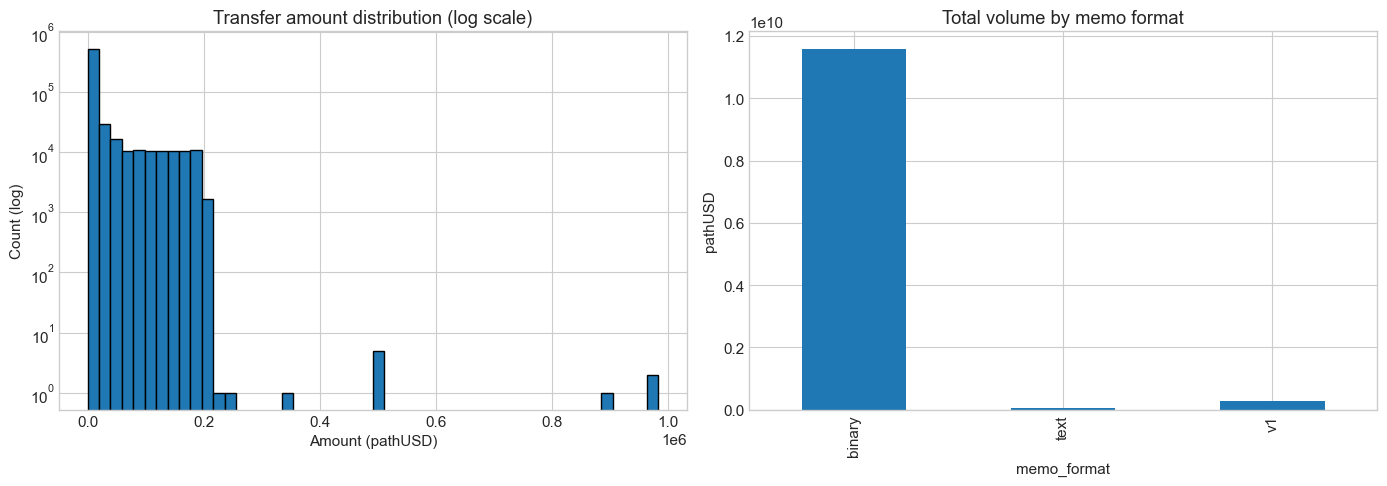

Total volume: 11,895,623,082.65 pathUSD
Median transfer: 12.00 pathUSD
Mean transfer: 18161.81 pathUSD
Max transfer: 984,198.00 pathUSD
Min transfer: 0.000001 pathUSD


In [8]:
df['amount_usd'] = df.amount_raw / 1e6

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

df.amount_usd.hist(ax=ax1, bins=50, edgecolor='black', log=True)
ax1.set_title('Transfer amount distribution (log scale)')
ax1.set_xlabel('Amount (pathUSD)')
ax1.set_ylabel('Count (log)')

# Amount by format
df.groupby('memo_format')['amount_usd'].sum().plot.bar(ax=ax2)
ax2.set_title('Total volume by memo format')
ax2.set_ylabel('pathUSD')

plt.tight_layout()
plt.show()

print(f'Total volume: {df.amount_usd.sum():,.2f} pathUSD')
print(f'Median transfer: {df.amount_usd.median():.2f} pathUSD')
print(f'Mean transfer: {df.amount_usd.mean():.2f} pathUSD')
print(f'Max transfer: {df.amount_usd.max():,.2f} pathUSD')
print(f'Min transfer: {df.amount_usd.min():.6f} pathUSD')

## Top senders and receivers

Top 10 senders by event count:
  0x290339Fc8304...   3633 events,        11.83 pathUSD
  0x4062163054EC...   2250 events,   266,650.00 pathUSD
  0x35a13B58b6f2...    275 events,         2.75 pathUSD
  0xad4D51220aFf...    230 events,     5,682.08 pathUSD
  0x80D237D124bb...    223 events,     4,009.08 pathUSD
  0x4DFF4a4d593D...    220 events,     3,923.07 pathUSD
  0x1FFb6f1664F0...    217 events,     4,928.02 pathUSD
  0x32a9dc04D8F2...    216 events,     5,995.93 pathUSD
  0xa47c8b1324C3...    215 events,     4,547.98 pathUSD
  0x7852254515bd...    215 events,     4,421.95 pathUSD

Top 10 receivers by event count:
  0x8d0755b9395C...   4463 events, 387,377,293.00 pathUSD
  0x7DFd67F4Bcb8...   4454 events, 391,011,608.00 pathUSD
  0xAE254C7FFa8d...   4436 events, 389,429,302.00 pathUSD
  0x221bBE7957Bf...   4427 events, 379,144,894.00 pathUSD
  0x6e4bCd2cFe51...   4417 events, 391,445,703.00 pathUSD
  0xD6B0ba6627FB...   4415 events, 393,775,540.00 pathUSD
  0x4BdF24038562...   4414 

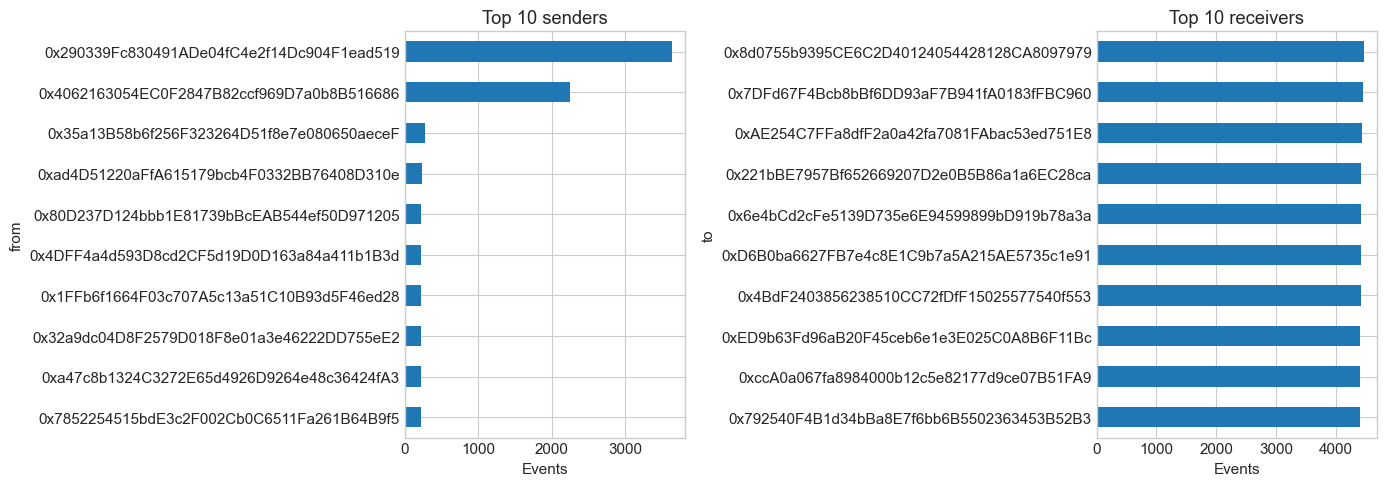

In [9]:
print('Top 10 senders by event count:')
top_senders = df['from'].value_counts().head(10)
for addr, count in top_senders.items():
    vol = df[df['from'] == addr].amount_usd.sum()
    print(f'  {addr[:14]}... {count:>6} events, {vol:>12,.2f} pathUSD')

print(f'\nTop 10 receivers by event count:')
top_receivers = df['to'].value_counts().head(10)
for addr, count in top_receivers.items():
    vol = df[df['to'] == addr].amount_usd.sum()
    print(f'  {addr[:14]}... {count:>6} events, {vol:>12,.2f} pathUSD')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

top_senders.plot.barh(ax=ax1)
ax1.set_title('Top 10 senders')
ax1.set_xlabel('Events')
ax1.invert_yaxis()

top_receivers.plot.barh(ax=ax2)
ax2.set_title('Top 10 receivers')
ax2.set_xlabel('Events')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

## Memo reuse patterns

Are memos unique per transfer, or do people reuse them?

In [10]:
memo_reuse = df.memo_raw.value_counts()
print(f'Total unique memos: {len(memo_reuse):,}')
print(f'Used once: {(memo_reuse == 1).sum():,} ({(memo_reuse == 1).sum()/len(memo_reuse)*100:.1f}%)')
print(f'Used 2+ times: {(memo_reuse > 1).sum():,}')
print(f'Used 10+ times: {(memo_reuse >= 10).sum():,}')
print(f'Used 100+ times: {(memo_reuse >= 100).sum():,}')

print(f'\nTop 20 most reused memos:')
for raw, count in memo_reuse.head(20).items():
    row = df[df.memo_raw == raw].iloc[0]
    print(f'  {count:>5}x  [{row.memo_format}] {row.memo_decoded}')

Total unique memos: 289,490
Used once: 281,769 (97.3%)
Used 2+ times: 7,721
Used 10+ times: 1,258
Used 100+ times: 106

Top 20 most reused memos:
  268444x  [text] test-memo
    854x  [text] drop
    844x  [text] flick
    830x  [text] block
    827x  [text] crypto
    823x  [text] bit
    821x  [text] snap
    816x  [text] pulse
    815x  [text] glow
    810x  [text] hash
    802x  [text] flux
    798x  [text] mint
    797x  [text] tap
    796x  [text] node
    789x  [text] chain
    788x  [text] drip
    779x  [text] rise
    773x  [text] beam
    752x  [text] flash
    749x  [text] spark


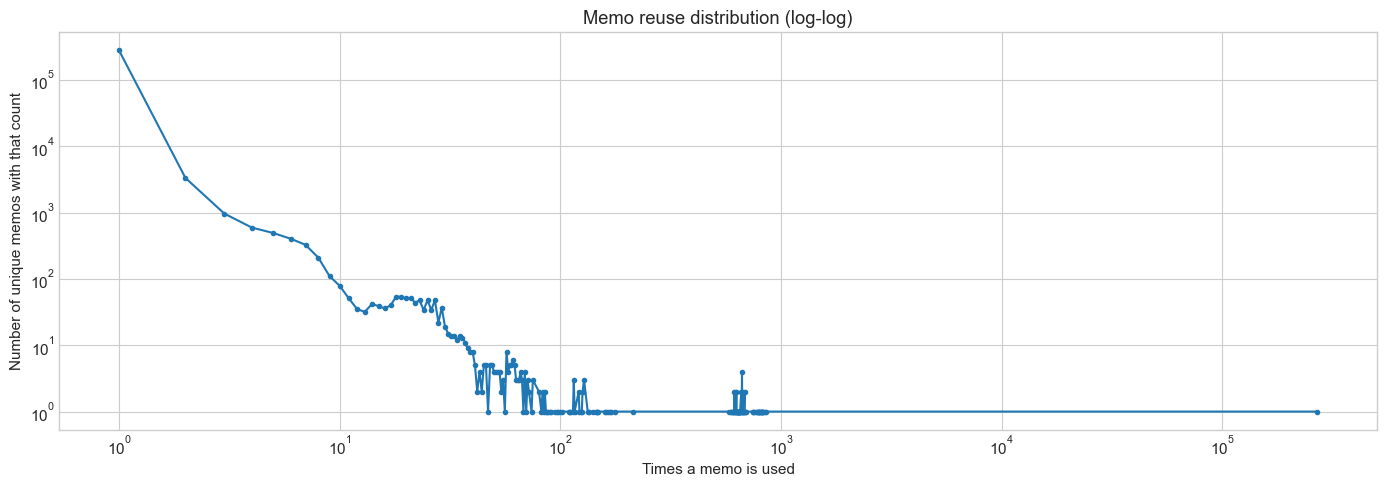

In [11]:
fig, ax = plt.subplots(figsize=(14, 5))
memo_reuse.value_counts().sort_index().plot(ax=ax, loglog=True, marker='.')
ax.set_title('Memo reuse distribution (log-log)')
ax.set_xlabel('Times a memo is used')
ax.set_ylabel('Number of unique memos with that count')
plt.tight_layout()
plt.show()

## Sender-receiver pairs

Are there repeated payment channels (same sender → same receiver)?

In [12]:
pairs = df.groupby(['from', 'to']).agg(
    events=('tx_hash', 'count'),
    total_usd=('amount_usd', 'sum'),
    unique_memos=('memo_raw', 'nunique'),
).sort_values('events', ascending=False)

print(f'Unique sender→receiver pairs: {len(pairs):,}')
print(f'Pairs with 10+ events: {(pairs.events >= 10).sum():,}')
print(f'Pairs with 100+ events: {(pairs.events >= 100).sum():,}\n')

print('Top 15 payment channels:')
for (sender, receiver), row in pairs.head(15).iterrows():
    print(f'  {sender[:10]}→{receiver[:10]}  {row.events:>5} events  {row.total_usd:>10,.2f} USD  {row.unique_memos} unique memos')

Unique sender→receiver pairs: 564,995
Pairs with 10+ events: 910
Pairs with 100+ events: 5

Top 15 payment channels:
  0x290339Fc→0x290339Fc  3632.0 events       11.83 USD  3632.0 unique memos
  0x40621630→0xabE8589a  1550.0 events  155,000.00 USD  42.0 unique memos
  0x40621630→0x1d655E64  511.0 events  102,200.00 USD  42.0 unique memos
  0x40621630→0x5eEf2268  189.0 events    9,450.00 USD  40.0 unique memos
  0xf39Fd6e5→0xB48141c3  105.0 events        0.22 USD  105.0 unique memos
  0x2b73C666→0x446a9948   55.0 events        0.55 USD  55.0 unique memos
  0x58Aa7CE4→0xDd6Fe700   53.0 events    2,650.00 USD  33.0 unique memos
  0xC7b38abA→0x5D95f55a   48.0 events        2.40 USD  48.0 unique memos
  0x86e8d305→0x051ee50e   46.0 events        0.46 USD  46.0 unique memos
  0x462bA767→0x5D95f55a   43.0 events        2.15 USD  43.0 unique memos
  0x94Ef9C6a→0x00DfEe79   40.0 events        0.60 USD  40.0 unique memos
  0x86e8d305→0xe144345d   40.0 events        0.62 USD  40.0 unique memos
  

## Pattern detection

Look for patterns in text memos: prefixes, numbering, structure.

In [13]:
text_df = df[df.memo_format == 'text'].copy()

# Check for common prefixes/patterns
text_df['has_dash'] = text_df.memo_decoded.str.contains('-', na=False)
text_df['has_number'] = text_df.memo_decoded.str.contains(r'\d', na=False)
text_df['starts_upper'] = text_df.memo_decoded.str[0].str.isupper()
text_df['all_lower'] = text_df.memo_decoded.str.islower()

print('Text memo patterns:')
print(f'  Contains dash: {text_df.has_dash.sum():,} ({text_df.has_dash.mean()*100:.1f}%)')
print(f'  Contains digit: {text_df.has_number.sum():,} ({text_df.has_number.mean()*100:.1f}%)')
print(f'  Starts uppercase: {text_df.starts_upper.sum():,} ({text_df.starts_upper.mean()*100:.1f}%)')
print(f'  All lowercase: {text_df.all_lower.sum():,} ({text_df.all_lower.mean()*100:.1f}%)')

# Extract first word as potential "prefix"
text_df['first_word'] = text_df.memo_decoded.str.split().str[0]
print(f'\nTop 20 first words:')
print(text_df.first_word.value_counts().head(20).to_string())

Text memo patterns:
  Contains dash: 358,596 (74.3%)
  Contains digit: 145,700 (30.2%)
  Starts uppercase: 137,736 (28.5%)
  All lowercase: 331,951 (68.7%)

Top 20 first words:
first_word
test-memo    268444
Message        9325
Memo           9300
Note           9059
Invoice        3264
Payment        2292
Order          1269
Refund         1266
drop            858
flick           844
block           830
crypto          829
pulse           823
bit             823
snap            822
glow            822
hash            810
flux            802
mint            798
tap             797


## Chain growth phases

Weekly breakdown — events, volume, unique addresses, format evolution.

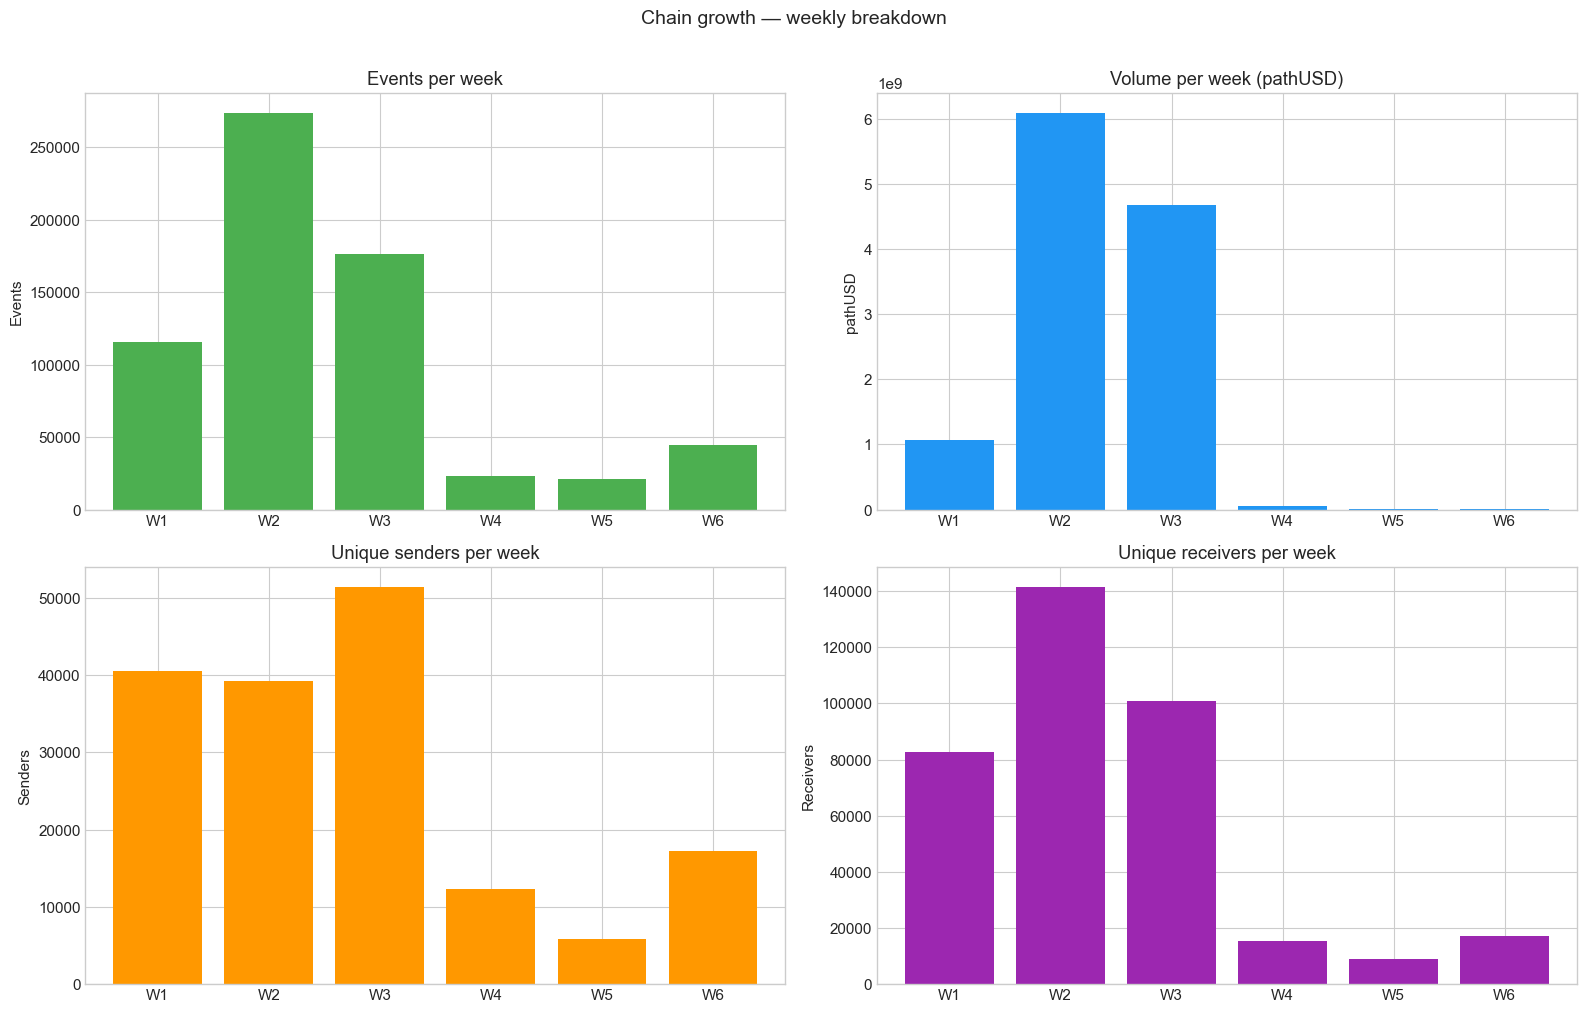

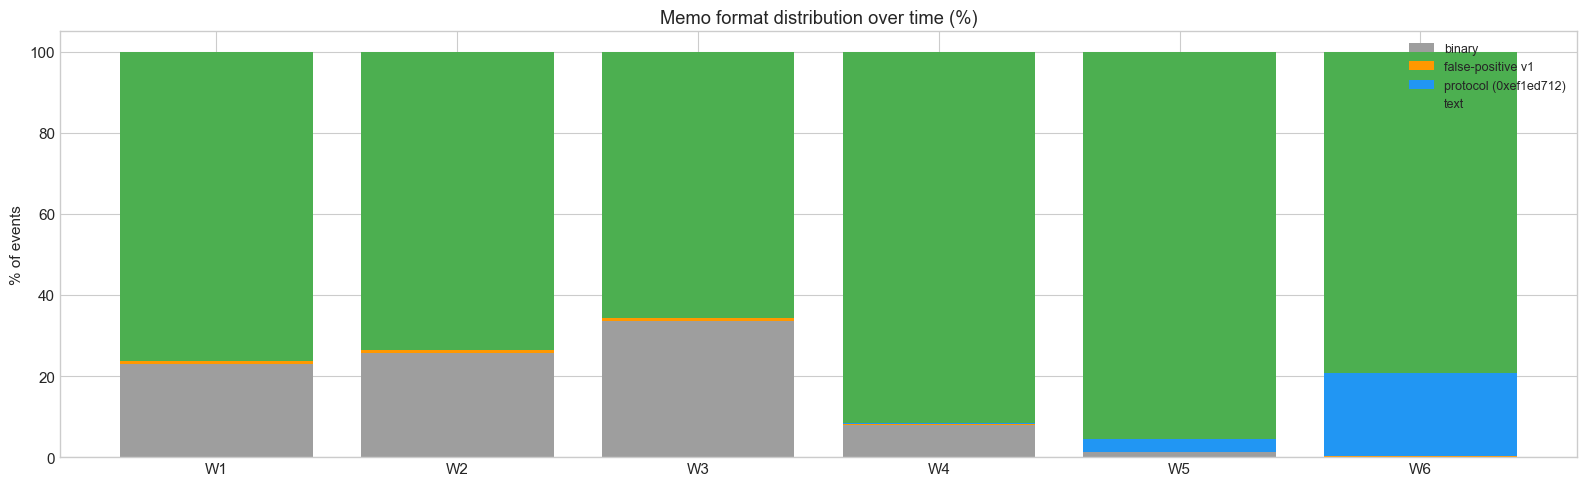

In [14]:
# Split chain into weekly windows for growth analysis
BLOCKS_PER_WEEK = 7200 * 24 * 7  # ~1 week at 0.5s/block
df['week_bin'] = (df.block_number // BLOCKS_PER_WEEK) * BLOCKS_PER_WEEK

weekly = df.groupby('week_bin').agg(
    events=('tx_hash', 'count'),
    volume=('amount_usd', 'sum'),
    senders=('from', 'nunique'),
    receivers=('to', 'nunique'),
)

n_weeks = len(weekly)
week_labels = [f'W{i+1}' for i in range(n_weeks)]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

weekly.events.plot(ax=axes[0, 0], kind='bar', color='#4CAF50', width=0.8)
axes[0, 0].set_title('Events per week')
axes[0, 0].set_ylabel('Events')

weekly.volume.plot(ax=axes[0, 1], kind='bar', color='#2196F3', width=0.8)
axes[0, 1].set_title('Volume per week (pathUSD)')
axes[0, 1].set_ylabel('pathUSD')

weekly.senders.plot(ax=axes[1, 0], kind='bar', color='#FF9800', width=0.8)
axes[1, 0].set_title('Unique senders per week')
axes[1, 0].set_ylabel('Senders')

weekly.receivers.plot(ax=axes[1, 1], kind='bar', color='#9C27B0', width=0.8)
axes[1, 1].set_title('Unique receivers per week')
axes[1, 1].set_ylabel('Receivers')

for ax in axes.flat:
    ax.set_xlabel('')
    ax.set_xticklabels(week_labels[:len(ax.get_xticklabels())], rotation=0)

plt.suptitle('Chain growth — weekly breakdown', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Format distribution evolution over time
fmt_weekly = df.groupby(['week_bin', 'true_format']).size().unstack(fill_value=0)
fmt_weekly_pct = fmt_weekly.div(fmt_weekly.sum(axis=1), axis=0) * 100

# Build color list matching actual columns (robust to missing categories)
bar_colors = [COLOR_MAP.get(col, '#ccc') for col in fmt_weekly_pct.columns]

fig, ax = plt.subplots(figsize=(16, 5))
fmt_weekly_pct.plot.bar(ax=ax, stacked=True, width=0.8, color=bar_colors)
ax.set_title('Memo format distribution over time (%)')
ax.set_ylabel('% of events')
ax.set_xlabel('')
ax.set_xticklabels(week_labels[:len(ax.get_xticklabels())], rotation=0)
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

## Summary

Full chain history analysis — every TransferWithMemo event since block 0.

In [15]:
total = len(df)
df['amount_usd'] = df.amount_raw / 1e6

right_text = (df.true_format == 'text').sum()
left_text_n = (df.true_format == 'left-padded text').sum()
ef_count = (df.true_format == 'protocol (0xef1ed712)').sum()
fp_v1 = (df.true_format == 'false-positive v1').sum()
true_bin = (df.true_format == 'binary').sum()
all_text_n = right_text + left_text_n

block_span = df.block_number.max() - df.block_number.min()
days = block_span * 0.5 / 86400

print('=' * 65)
print(f'MEMO LANDSCAPE -- FULL CHAIN ({days:.0f} DAYS ON MODERATO)')
print('=' * 65)
print(f'Block range:                    {df.block_number.min():,.0f} -- {df.block_number.max():,.0f}')
print(f'Total blocks scanned:           {block_span:>10,.0f}')
print(f'Total TransferWithMemo events:  {total:>10,}')
print(f'  Right-padded text:            {right_text:>10,} ({right_text/total*100:.1f}%)')
print(f'  Left-padded text:             {left_text_n:>10,} ({left_text_n/total*100:.1f}%)')
print(f'  0xef1ed712 protocol:          {ef_count:>10,} ({ef_count/total*100:.1f}%)')
print(f'  False-positive v1:            {fp_v1:>10,} ({fp_v1/total*100:.1f}%)')
print(f'  True binary:                  {true_bin:>10,} ({true_bin/total*100:.1f}%)')
print()
print(f'All human-readable text:        {all_text_n:>10,} ({all_text_n/total*100:.1f}%)')
print(f'Unique memo values:             {df.memo_raw.nunique():>10,}')
print(f'Total volume:                   {df.amount_usd.sum():>14,.2f} pathUSD')
print(f'Unique senders:                 {df["from"].nunique():>10,}')
print(f'Unique receivers:               {df["to"].nunique():>10,}')
print()
print('FINDINGS:')
print(f'  1. ~{all_text_n/total*100:.0f}% of memos are human-readable text (invoices, notes, labels)')
print(f'  2. Left-padded text ({left_text_n/total*100:.1f}%) from Solidity bytes32 cast')
print(f'  3. Real invoice refs: "Invoice #2026-906", "INV-424 - Maintenance Contract"')
print(f'  4. Real payroll: "Salary - Jan 2026", "PAYROLL_BATCH_960_EXEC"')
print(f'  5. Real business: "Content writing", "Website redesign", "Monthly SaaS"')
print(f'  6. 0 real v1 structured memos. {fp_v1:,} false positives (random bytes with valid type byte)')
print(f'  7. 0xef1ed712 is a separate protocol (unique IDs, tiny amounts, attestation-like)')
print()
print('WHAT THIS MEANS FOR STRUCTURED MEMOS:')
print('  People already use memos for payment context. The problems:')
print(f'  - Two padding schemes (left/right) that break each other\'s decoders')
print(f'  - No namespacing: "INV-001" from app A collides with "INV-001" from app B')
print(f'  - No unique IDs: manual numbering (dinner001, dinner002...)')
print(f'  - No machine-readable type: can\'t filter "all payroll memos" without regex')
print()
print('  v1 format addresses these by putting type, issuerTag, and ULID in fixed offsets.')
print('  decodeMemo() reads both legacy text and v1, so existing memos keep working.')

MEMO LANDSCAPE -- FULL CHAIN (38 DAYS ON MODERATO)
Block range:                    17,538 -- 6,643,148
Total blocks scanned:            6,625,610
Total TransferWithMemo events:     654,980
  Right-padded text:               482,842 (73.7%)
  Left-padded text:                      0 (0.0%)
  0xef1ed712 protocol:               9,921 (1.5%)
  False-positive v1:                 3,850 (0.6%)
  True binary:                     158,367 (24.2%)

All human-readable text:           482,842 (73.7%)
Unique memo values:                289,490
Total volume:                   11,895,623,082.65 pathUSD
Unique senders:                     88,072
Unique receivers:                  353,961

FINDINGS:
  1. ~74% of memos are human-readable text (invoices, notes, labels)
  2. Left-padded text (0.0%) from Solidity bytes32 cast
  3. Real invoice refs: "Invoice #2026-906", "INV-424 - Maintenance Contract"
  4. Real payroll: "Salary - Jan 2026", "PAYROLL_BATCH_960_EXEC"
  5. Real business: "Content writing", "W